In [1]:
import pandas as pd
import joblib

df = pd.read_csv("student_scores_cleaned.csv")
model = joblib.load("student_score_model.pkl")

print("Model loaded successfully!")
print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Model loaded successfully!
Slope (m): 8.628717396388677
Intercept (b): 3.3353139672017633


In [2]:
from sklearn.model_selection import train_test_split

X = df[["StudyHours"]]
y = df["Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Test samples:", X_test.shape[0])

Test samples: 10


In [3]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "StudyHours": X_test["StudyHours"].values,
    "ActualScore": y_test.values,
    "PredictedScore": y_pred.round(2)
})

results.sort_values("StudyHours").reset_index(drop=True)

,StudyHours,ActualScore,PredictedScore
0,1.6,14.2,17.14
1,2.8,24.8,27.50
2,2.9,29.2,28.36
3,3.6,37.3,34.40
4,5.0,35.1,46.48
5,5.7,49.8,52.52
6,5.9,50.5,54.24
7,6.5,60.3,59.42
8,7.0,60.5,63.74
9,8.1,79.7,73.23


In [4]:
new_hours = pd.DataFrame({"StudyHours": [1, 3, 5, 7, 9, 10]})
new_predictions = model.predict(new_hours)

for hours, score in zip(new_hours["StudyHours"], new_predictions):
    print(f"Study Hours: {hours} -> Predicted Score: {round(score, 2)}")

Study Hours: 1 -> Predicted Score: 11.96
Study Hours: 3 -> Predicted Score: 29.22
Study Hours: 5 -> Predicted Score: 46.48
Study Hours: 7 -> Predicted Score: 63.74
Study Hours: 9 -> Predicted Score: 80.99
Study Hours: 10 -> Predicted Score: 89.62


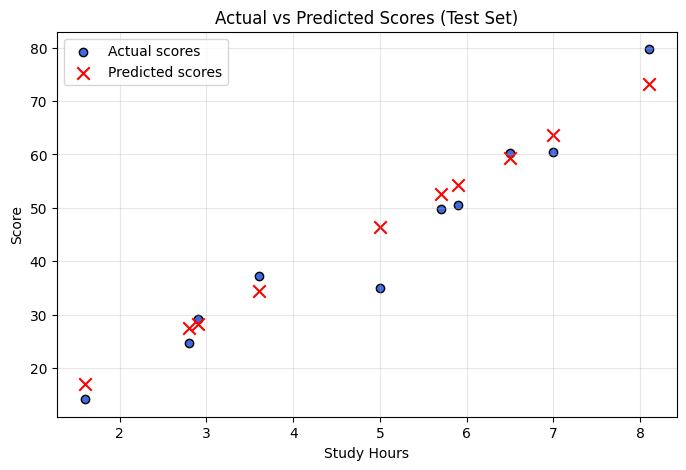

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color="royalblue", edgecolor="black", label="Actual scores")
plt.scatter(X_test, y_pred, color="red", marker="x", s=80, label="Predicted scores")
plt.title("Actual vs Predicted Scores (Test Set)")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("day9_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()